In [1]:
#Packages
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#***Read the csv files***

In [2]:
df_features=pd.read_csv("Features_data_set.csv")
df_features

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [4]:
df_stores=pd.read_csv("stores_data_set.csv")
df_stores

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [5]:
df_sales= pd.read_csv("sales_data_set.csv")
df_sales

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False
...,...,...,...,...,...
421565,45,98,28/09/2012,508.37,False
421566,45,98,05/10/2012,628.10,False
421567,45,98,12/10/2012,1061.02,False
421568,45,98,19/10/2012,760.01,False


#***Mergeing the store data***

In [6]:
# combine store and sales dataframe into single dataframe based on 'store' column(Features and stores)
df1=pd.merge(df_features,df_stores,on="Store",how="inner")
df1

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False,B,118221
8186,45,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False,B,118221
8187,45,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False,B,118221
8188,45,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False,B,118221


In [7]:
# combine store and feature dataframe into single datarame based on 'store' column(Sales and stores)
df2=pd.merge(df_sales,df_stores,on="Store",how="inner")
df2

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
0,1,1,05/02/2010,24924.50,False,A,151315
1,1,1,12/02/2010,46039.49,True,A,151315
2,1,1,19/02/2010,41595.55,False,A,151315
3,1,1,26/02/2010,19403.54,False,A,151315
4,1,1,05/03/2010,21827.90,False,A,151315
...,...,...,...,...,...,...,...
421565,45,98,28/09/2012,508.37,False,B,118221
421566,45,98,05/10/2012,628.10,False,B,118221
421567,45,98,12/10/2012,1061.02,False,B,118221
421568,45,98,19/10/2012,760.01,False,B,118221


In [7]:
#df1 have (2010 to 2013) and df2 have (2010 to 2012)
#so we need to splite the df1's (2010 to 2012)

#***spliting and merging***

In [8]:
#creating the commen columns for merging
# create unique column (diff) for the combination of store and date
df1["diffe"]=df1["Store"].astype(str)+"-"+df1["Date"]
df2["diffe"]=df2["Store"].astype(str)+"-"+df2["Date"]

In [12]:
#Filter rows from `df1` where "diffe" exists in `df2`, reset the index, and display the last 3 rows.
df1_inlist= df1[df1["diffe"].isin(df2["diffe"])]
df1_inlist.reset_index(drop=True,inplace=True)
df1_inlist.tail(3)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size,diffe
6432,45,12/10/2012,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,False,B,118221,45-12/10/2012
6433,45,19/10/2012,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,False,B,118221,45-19/10/2012
6434,45,26/10/2012,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,False,B,118221,45-26/10/2012


In [11]:

#Filter rows from `df1` where "diffe" is not in `df2`, reset the index, and show the last 3 rows.
df1_notinlist=df1[~df1["diffe"].isin(df2["diffe"])]
df1_notinlist.reset_index(drop=True,inplace=True)
df1_notinlist.tail(3)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size,diffe
1752,45,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False,B,118221,45-12/07/2013
1753,45,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False,B,118221,45-19/07/2013
1754,45,26/07/2013,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,False,B,118221,45-26/07/2013


In [13]:
#checking the shape and the unique values
df1.shape,df1_inlist.shape,df1_notinlist.shape

((8190, 15), (6435, 15), (1755, 15))

In [14]:
#Total rows in df1   ==> 8190
#2010 to 2012 in df1 ==> 6435
#2012 to 2013 in df1 ==> 1755

In [ ]:
df1["diffe"].nunique(),df1_inlist["diffe"].nunique(),df1_notinlist["diffe"].nunique()
#so we don't have any duplicate values in the df1

(8190, 6435, 1755)

In [18]:
# Merge df2 and df1_inlist on the "diffe" column using an inner join to create df3.
df3=pd.merge(df2,df1_inlist,on="diffe",how="inner")

In [19]:
# displaying columns
df3.columns


Index(['Store_x', 'Dept', 'Date_x', 'Weekly_Sales', 'IsHoliday_x', 'Type_x',
       'Size_x', 'diffe', 'Store_y', 'Date_y', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'IsHoliday_y', 'Type_y', 'Size_y'],
      dtype='object')

In [20]:
#droping the dublicate columns

df3.drop(columns=['Store_y','Date_y','IsHoliday_y','Type_y','Size_y'],inplace=True)

In [21]:
#rename the columns
df3.rename(columns={"Store_x":"Store","Date_x":"Date","IsHoliday_x":"IsHoliday","Type_x":"Type","Size_x":"Size"},inplace=True)

In [22]:
# Now we want to  merge the dataframe df3 and df1_notinlist(2012 - 2013) row wise
# But df3 have a "Dept" and df1_notinlist have not "Dept"
# So we want to add the "Dept" column in df1_notinlist

In [23]:
# Take the "Dept" column from sales Dataset

sd=df_sales[["Store","Dept"]]
sd

,Store,Dept
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
421565,45,98
421566,45,98
421567,45,98
421568,45,98


In [25]:
#Remove duplicate rows based on the "Store" and "Dept" columns, reset the index, and display the last 3 rows.
sd.drop_duplicates(subset=["Store","Dept"],inplace=True)
sd.reset_index(drop=True, inplace=True)
sd.tail(3)

,Store,Dept
3328,45,96
3329,45,97
3330,45,98


In [26]:
df1_notinlist

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size,diffe
0,1,02/11/2012,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,False,A,151315,1-02/11/2012
1,1,09/11/2012,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,False,A,151315,1-09/11/2012
2,1,16/11/2012,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,False,A,151315,1-16/11/2012
3,1,23/11/2012,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,True,A,151315,1-23/11/2012
4,1,30/11/2012,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,False,A,151315,1-30/11/2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1750,45,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False,B,118221,45-28/06/2013
1751,45,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False,B,118221,45-05/07/2013
1752,45,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False,B,118221,45-12/07/2013
1753,45,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False,B,118221,45-19/07/2013


In [27]:
df4= pd.merge(sd,df1_notinlist,on="Store",how="outer")
df4

,Store,Dept,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size,diffe
0,1,1,02/11/2012,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,False,A,151315,1-02/11/2012
1,1,1,09/11/2012,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,False,A,151315,1-09/11/2012
2,1,1,16/11/2012,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,False,A,151315,1-16/11/2012
3,1,1,23/11/2012,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,True,A,151315,1-23/11/2012
4,1,1,30/11/2012,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,False,A,151315,1-30/11/2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129904,45,98,28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False,B,118221,45-28/06/2013
129905,45,98,05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False,B,118221,45-05/07/2013
129906,45,98,12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False,B,118221,45-12/07/2013
129907,45,98,19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False,B,118221,45-19/07/2013


In [ ]:
#Concatenate df3 and df4 into df5, reset the index, and display the resulting dataframe. 
df5=pd.concat([df3,df4])
df5.reset_index(drop=True,inplace=True)
df5

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,diffe,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,05/02/2010,24924.50,False,A,151315,1-05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,2,05/02/2010,50605.27,False,A,151315,1-05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
2,1,3,05/02/2010,13740.12,False,A,151315,1-05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
3,1,4,05/02/2010,39954.04,False,A,151315,1-05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
4,1,5,05/02/2010,32229.38,False,A,151315,1-05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,45,98,28/06/2013,NaN,False,B,118221,45-28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN
551475,45,98,05/07/2013,NaN,False,B,118221,45-05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN
551476,45,98,12/07/2013,NaN,False,B,118221,45-12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN
551477,45,98,19/07/2013,NaN,False,B,118221,45-19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN


In [ ]:
# Datatype conversion using pandas
#Replace all "/" with "-" in the "Date" column of df5 and display the updated "Date" column.
df5["Date"]=df5["Date"].apply(lambda x: x.replace("/","-"))
df5["Date"]

0         05-02-2010
1         05-02-2010
2         05-02-2010
3         05-02-2010
4         05-02-2010
             ...    
551474    28-06-2013
551475    05-07-2013
551476    12-07-2013
551477    19-07-2013
551478    26-07-2013
Name: Date, Length: 551479, dtype: object

In [30]:
#Convert the "Date" column in `df5` to a datetime format (`dd-mm-yyyy`), coercing any errors, and display the updated "Date" column.
df5["Date"]= pd.to_datetime(df5["Date"],format="%d-%m-%Y",errors="coerce")
df5["Date"]

0        2010-02-05
1        2010-02-05
2        2010-02-05
3        2010-02-05
4        2010-02-05
            ...    
551474   2013-06-28
551475   2013-07-05
551476   2013-07-12
551477   2013-07-19
551478   2013-07-26
Name: Date, Length: 551479, dtype: datetime64[ns]

In [31]:
# encoding for catagorical features into numerical
# Convert the "IsHoliday" column in df5 from boolean values to 1 and 0, and map the "Type" column values from 'A', 'B', 'C' to 1, 2, and 3, respectively.

df5["IsHoliday"]= df5["IsHoliday"].map({False:0, True:1})
df5["Type"]= df5["Type"].map({"A":0,"B":1,"C":2})

In [32]:
df5

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,diffe,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,0,0,151315,1-05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,2,2010-02-05,50605.27,0,0,151315,1-05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
2,1,3,2010-02-05,13740.12,0,0,151315,1-05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
3,1,4,2010-02-05,39954.04,0,0,151315,1-05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
4,1,5,2010-02-05,32229.38,0,0,151315,1-05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,45,98,2013-06-28,NaN,0,1,118221,45-28/06/2013,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN
551475,45,98,2013-07-05,NaN,0,1,118221,45-05/07/2013,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN
551476,45,98,2013-07-12,NaN,0,1,118221,45-12/07/2013,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN
551477,45,98,2013-07-19,NaN,0,1,118221,45-19/07/2013,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN


In [33]:
# Drop the "differ" column from `df5`.
df5.drop(columns=["diffe"],inplace=True)

In [34]:
df5

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,0,0,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,2,2010-02-05,50605.27,0,0,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
2,1,3,2010-02-05,13740.12,0,0,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
3,1,4,2010-02-05,39954.04,0,0,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
4,1,5,2010-02-05,32229.38,0,0,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,45,98,2013-06-28,NaN,0,1,118221,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN
551475,45,98,2013-07-05,NaN,0,1,118221,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN
551476,45,98,2013-07-12,NaN,0,1,118221,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN
551477,45,98,2013-07-19,NaN,0,1,118221,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN


In [35]:
# Sort df5 by "Date", "Store", and "Dept" in ascending order.
df5=df5.sort_values(by=["Date","Store","Dept"])

In [37]:
#Reset the index of df5 and drop the old index.
df5.reset_index(drop=True,inplace=True)

In [39]:
# make Date feature into --> Day,Month,Year new features and drop Date column
df5["Day"]=df5["Date"].dt.day
df5["Month"]=df5["Date"].dt.month
df5["Year"]=df5["Date"].dt.year

In [40]:
df5.drop(columns=["Date"],inplace=True)

In [41]:
df5.columns

Index(['Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Day', 'Month',
       'Year'],
      dtype='object')

In [43]:
# rearrange the columns order
df5=df5[['Day','Month','Year','Store','Dept','Type','Weekly_Sales','Size','IsHoliday','Temperature',
           'Fuel_Price', 'MarkDown1', 'MarkDown2','MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']]

In [44]:
df5.describe()

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,551479.000000,551479.000000,551479.000000,551479.000000,551479.000000,551479.000000,421570.000000,551479.000000,551479.000000,551479.000000,551479.000000,280405.000000,207897.000000,254619.000000,248649.000000,281341.000000,508176.000000,508176.000000
mean,15.653488,6.277180,2011.392758,22.270485,44.603013,0.594791,15981.258123,136073.691863,0.071905,58.703624,3.413010,7369.403469,3489.575965,1859.728572,3355.891061,4261.631495,172.200115,7.775470
std,8.776044,3.340134,1.054086,12.796872,30.416079,0.669624,22711.183519,61207.331445,0.258330,18.685408,0.427725,9439.253385,8920.862286,11633.662079,6889.409946,13679.851274,39.595683,1.863253
min,1.000000,1.000000,2010.000000,1.000000,1.000000,0.000000,-4988.940000,34875.000000,0.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,8.000000,3.000000,2010.000000,11.000000,19.000000,0.000000,2079.650000,93638.000000,0.000000,45.160000,3.050000,2014.470000,74.240000,7.330000,319.190000,1524.870000,132.529129,6.614000
50%,16.000000,6.000000,2011.000000,22.000000,38.000000,0.000000,7612.030000,128107.000000,0.000000,59.940000,3.524000,5011.720000,397.960000,41.390000,1202.440000,2825.360000,182.517732,7.771000
75%,23.000000,9.000000,2012.000000,33.000000,74.000000,1.000000,20205.852500,202505.000000,0.000000,73.160000,3.746000,9264.480000,2359.440000,177.270000,3380.280000,4930.020000,213.871114,8.549000
max,31.000000,12.000000,2013.000000,45.000000,99.000000,2.000000,693099.360000,219622.000000,1.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


In [45]:
# check datatypes of all features and everything in numerical
df5.dtypes

Day               int64
Month             int64
Year              int64
Store             int64
Dept              int64
Type              int64
Weekly_Sales    float64
Size              int64
IsHoliday         int64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
dtype: object

In [37]:
# Weekly sales have a negative values
# so we want to change the negative values into null

In [46]:
# check null values of all features --> weekly_sales, markdown, cpi, unemplyment feature have null values
df5.isnull().sum()

Day                  0
Month                0
Year                 0
Store                0
Dept                 0
Type                 0
Weekly_Sales    129909
Size                 0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       271074
MarkDown2       343582
MarkDown3       296860
MarkDown4       302830
MarkDown5       270138
CPI              43303
Unemployment     43303
dtype: int64

In [48]:
# check negative weekly_sales count
df5[df5["Weekly_Sales"]<=0]

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
389,5,2,2010,6,47,0,-59.00,202505,0,40.43,2.572,NaN,NaN,NaN,NaN,NaN,212.622352,7.259
601,5,2,2010,9,49,1,-15.00,125833,0,38.01,2.572,NaN,NaN,NaN,NaN,NaN,214.655459,6.415
714,5,2,2010,11,19,0,0.00,207499,0,46.04,2.572,NaN,NaN,NaN,NaN,NaN,214.424881,7.368
1039,5,2,2010,15,80,1,-0.04,123737,0,19.83,2.954,NaN,NaN,NaN,NaN,NaN,131.527903,8.350
1345,5,2,2010,20,19,0,0.00,203742,0,25.92,2.784,NaN,NaN,NaN,NaN,NaN,204.247194,8.187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419896,26,10,2012,19,47,0,-18.00,203819,0,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992
419943,26,10,2012,20,19,0,-3.97,203742,0,60.04,3.882,10813.19,22.33,102.91,867.39,1671.76,216.151590,7.293
420601,26,10,2012,29,80,1,-178.15,93638,0,57.58,3.917,5581.80,2.98,NaN,398.23,396.11,138.728161,9.151
420972,26,10,2012,35,80,1,-16.51,103681,0,58.99,3.882,6221.06,42.48,103.00,273.90,996.79,142.762411,8.665


In [49]:
# negative weekly_sales value convert to null value
df5["Weekly_Sales"]=df5["Weekly_Sales"].apply(lambda x: np.nan if x<=0 else x)

In [50]:
# check null values of all features
df5.isnull().sum()

Day                  0
Month                0
Year                 0
Store                0
Dept                 0
Type                 0
Weekly_Sales    131267
Size                 0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       271074
MarkDown2       343582
MarkDown3       296860
MarkDown4       302830
MarkDown5       270138
CPI              43303
Unemployment     43303
dtype: int64

In [53]:
# MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5 - features have huge number of null values compare to other features
# create 'markdown' column for --> all markdowns are null means 0, otherwise 1 (any one markdown have value)
df5["Markdown"]=df5[["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]].notnull().any(axis=1)

In [54]:
# check weekly_sales average --> holiday(1) and non-holiday(0)
df5["Markdown"]=df5["Markdown"].map({True:1,False:0})

In [56]:
df5.groupby("Markdown")["Weekly_Sales"].mean()

Markdown
0    15922.137810
1    16231.116041
Name: Weekly_Sales, dtype: float64

In [57]:
#Compute the correlation matrix of the numerical columns in df5 and store the result in df5_corr.
df5_corr=df5.corr()

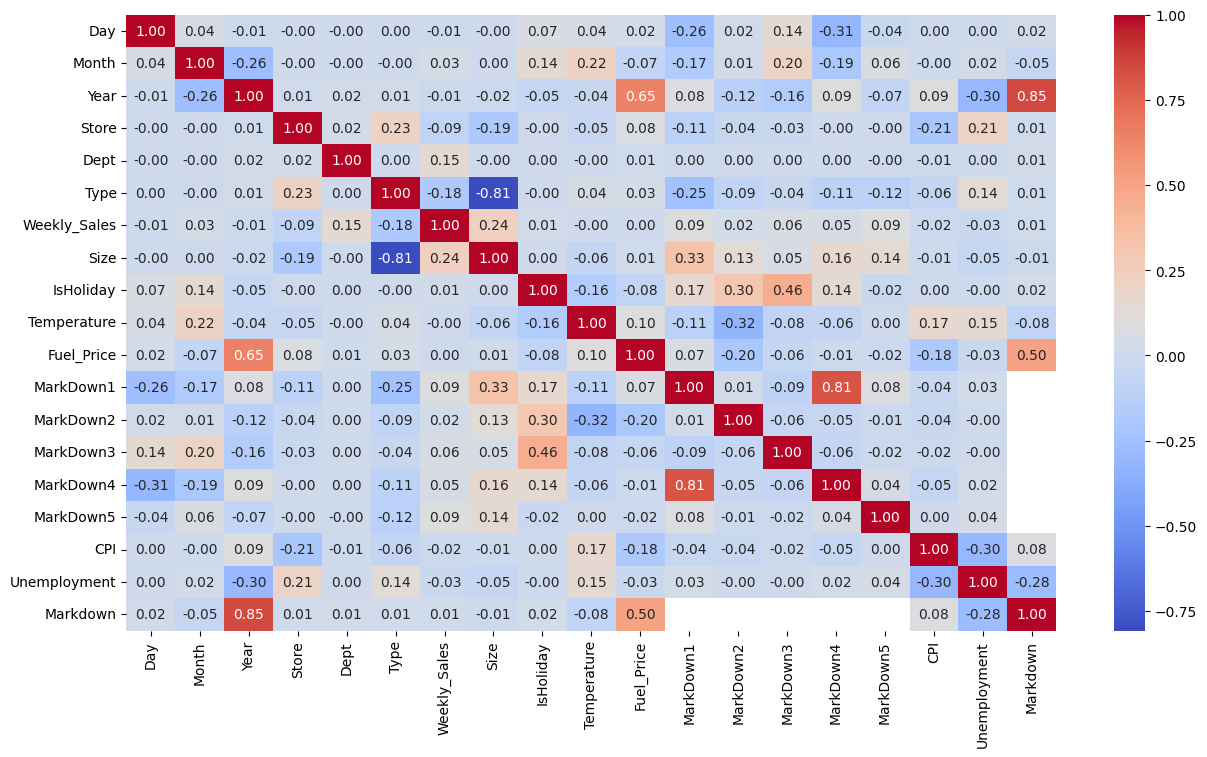

In [64]:
plt.figure(figsize=(15,8))
sns.heatmap(df5_corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

Univariate Analysis - Descriptive Statistics:


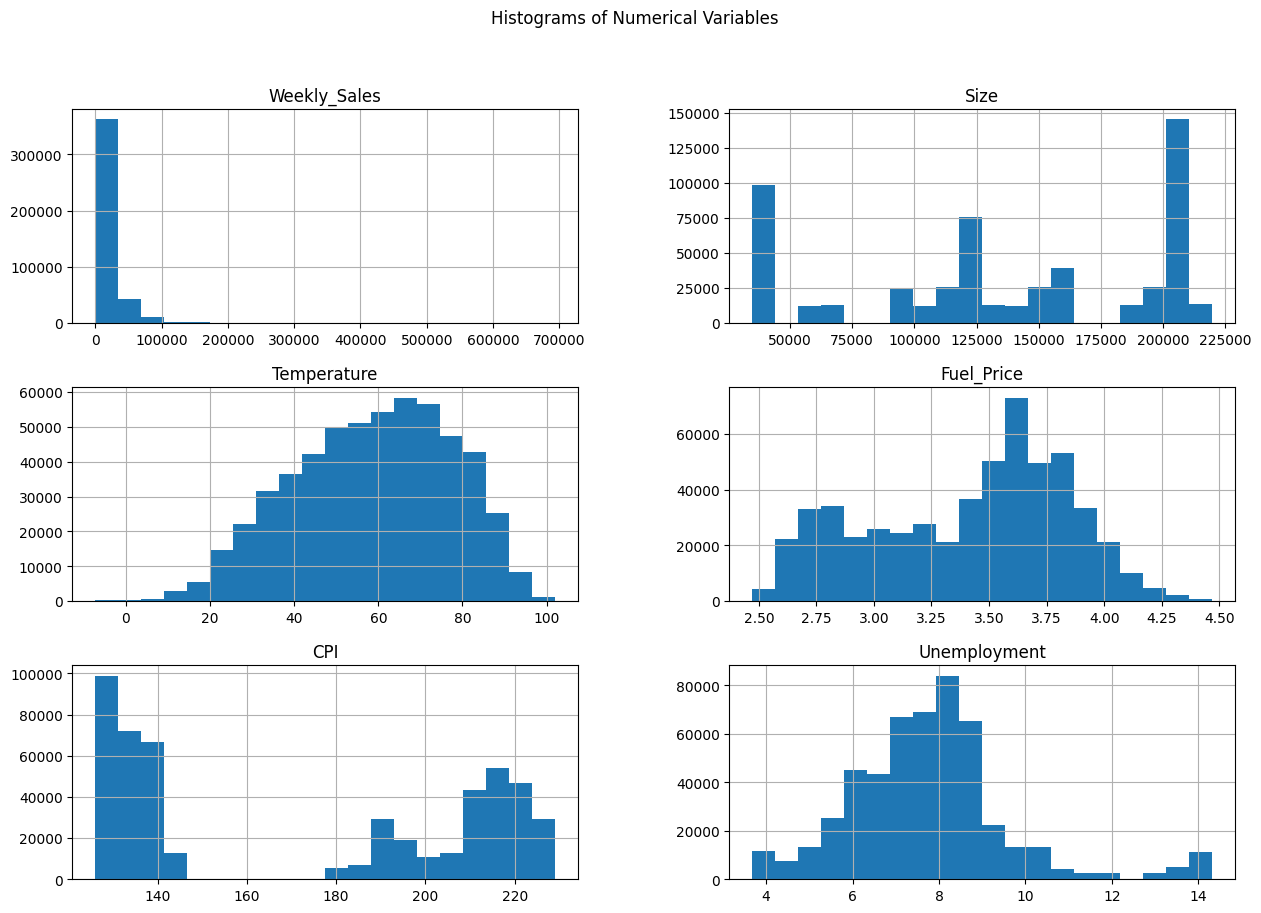

In [73]:

# Univariate Analysis
print("Univariate Analysis - Descriptive Statistics:")

# Histograms for Numerical Variables
df5[['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Variables')
plt.show()


#****Removed Null Values Correlation****#

In [66]:
df5_dropna_corr=df5_dropna.corr()

Univariate Analysis - Descriptive Statistics:


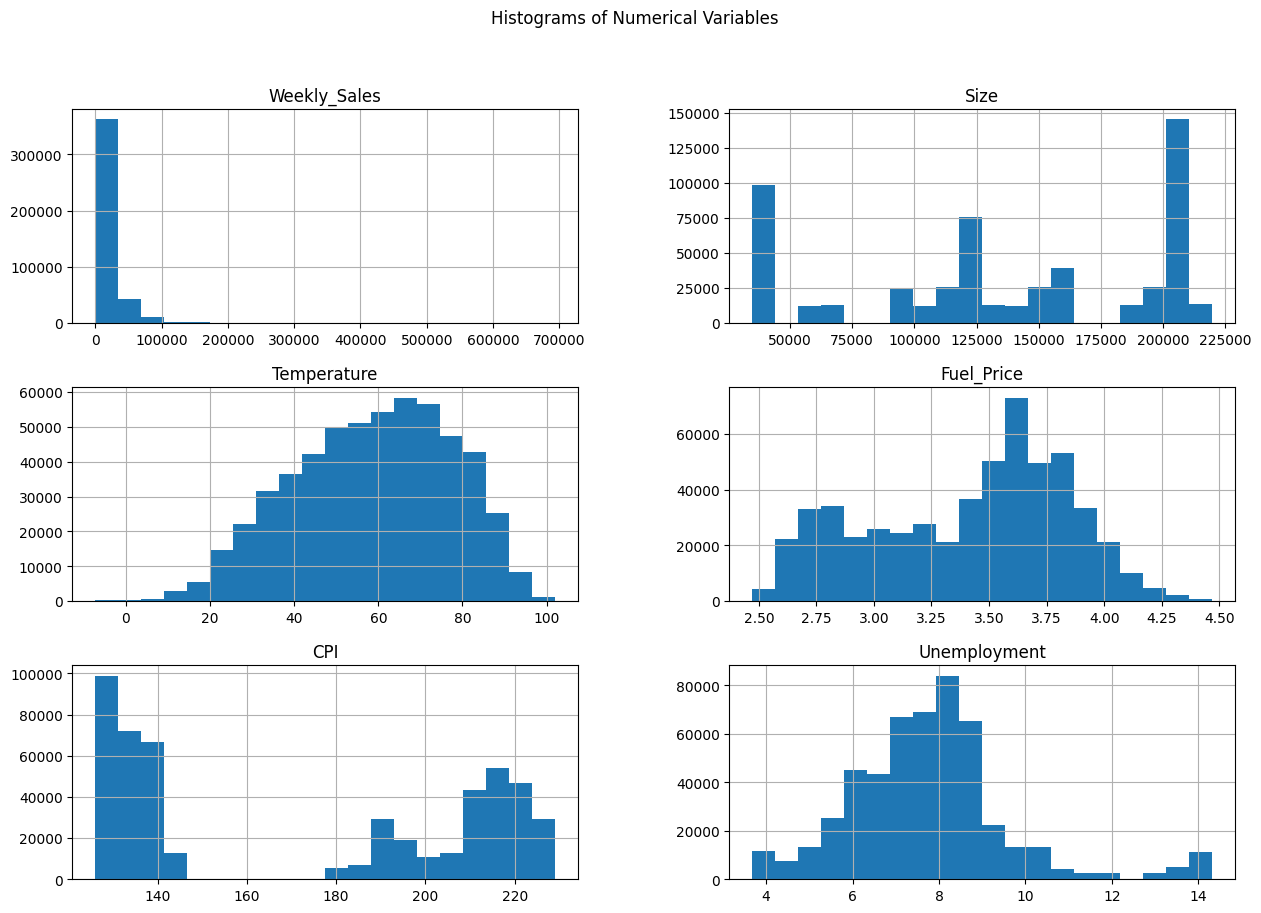

In [74]:

# Univariate Analysis
print("Univariate Analysis - Descriptive Statistics:")

# Histograms for Numerical Variables
df5[['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Variables')
plt.show()


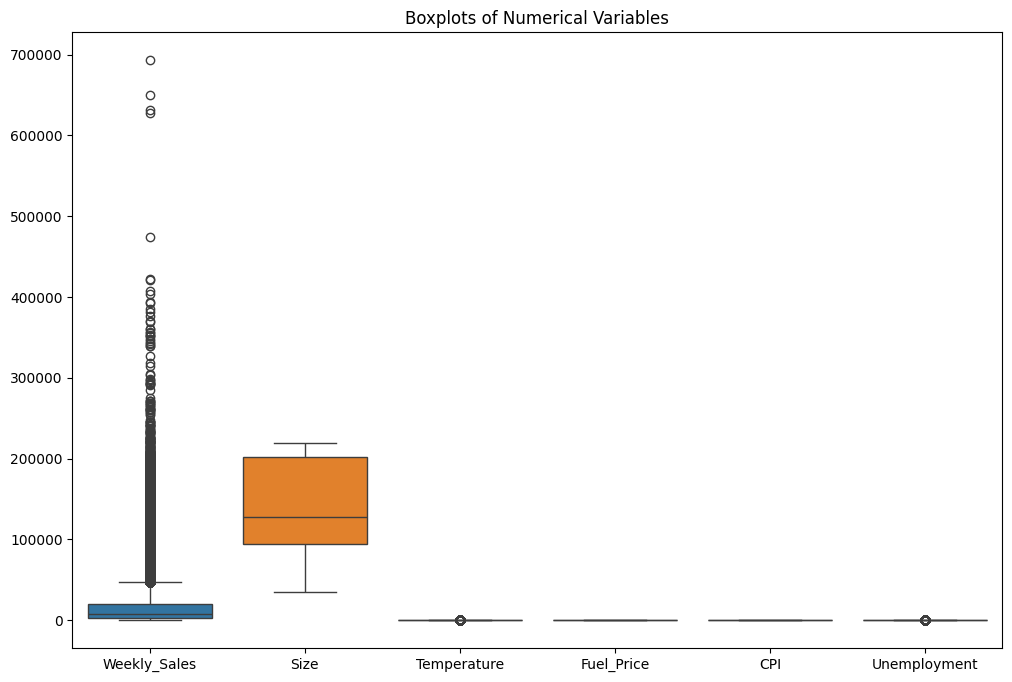

In [76]:
# Boxplots to Identify Outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df5[['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
plt.title('Boxplots of Numerical Variables')
plt.show()

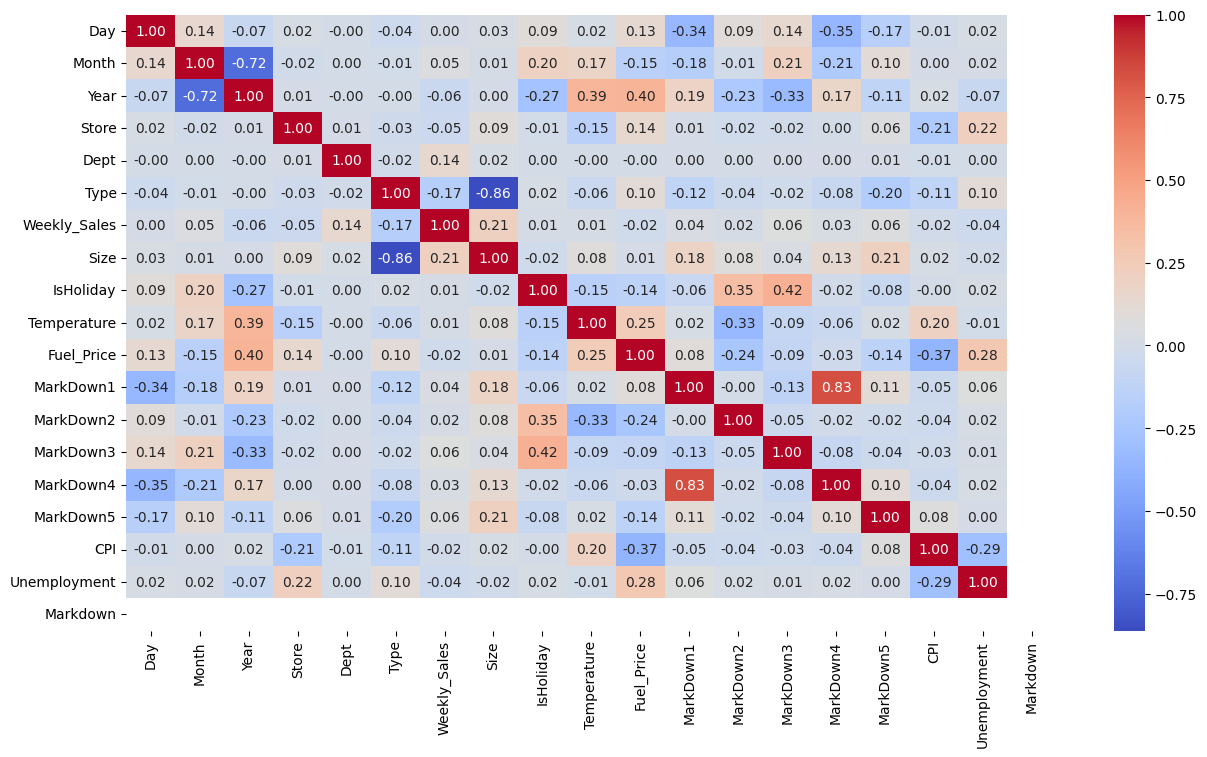

In [67]:
plt.figure(figsize=(15,8))
sns.heatmap(df5_dropna_corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

In [68]:
#Weekly salse have higly correlation with the "Size","Type","Dept"
#Other wise have low correlation

In [49]:
#creating a "differ" columns for the usage of merging other dataframes

In [69]:
df5["differ"]=df5["Day"].astype(str)+df5["Month"].astype(str)+df5["Year"].astype(str)+"-"+df5["Store"].astype(str)+"-"+df5["Dept"].astype(str)

In [72]:
# MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5 - features have huge number of null values compare to other features

# Model : Use all MarkDown features (MarkDown1 to MarkDown5) to predict weekly_sales

In [71]:
# check number of unique values in each features
df5.nunique()

Day                 31
Month               12
Year                 4
Store               45
Dept                81
Type                 3
Weekly_Sales    358785
Size                40
IsHoliday            2
Temperature       4178
Fuel_Price        1011
MarkDown1         4023
MarkDown2         2715
MarkDown3         2885
MarkDown4         3405
MarkDown5         4045
CPI               2505
Unemployment       404
Markdown             2
differ          551479
dtype: int64

In [53]:
df5.nunique()

Day                 31
Month               12
Year                 4
Store               45
Dept                81
Type                 3
Weekly_Sales    358785
Size                40
IsHoliday            2
Temperature       4178
Fuel_Price        1011
MarkDown1         4023
MarkDown2         2715
MarkDown3         2885
MarkDown4         3405
MarkDown5         4045
CPI               2505
Unemployment       404
Markdown             2
differ          551479
dtype: int64

In [77]:
#importing the ML packages for the model selection

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import pickle

In [78]:
df5

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Markdown,differ
0,5,2,2010,1,1,0,24924.50,151315,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,522010-1-1
1,5,2,2010,1,2,0,50605.27,151315,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,522010-1-2
2,5,2,2010,1,3,0,13740.12,151315,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,522010-1-3
3,5,2,2010,1,4,0,39954.04,151315,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,522010-1-4
4,5,2,2010,1,5,0,32229.38,151315,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,0,522010-1-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,7,2013,45,94,1,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1,2672013-45-94
551475,26,7,2013,45,95,1,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1,2672013-45-95
551476,26,7,2013,45,96,1,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1,2672013-45-96
551477,26,7,2013,45,97,1,NaN,118221,0,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,1,2672013-45-97


In [80]:
# Create a copy of df5 as df5_m1, drop the "Markdown" column, and then check the number of missing values (nulls) in each column of df5_m1.
df5_m1=df5.copy()
df5_m1.drop(columns=["Markdown"],inplace=True)
df5_m1.isnull().sum()

Day                  0
Month                0
Year                 0
Store                0
Dept                 0
Type                 0
Weekly_Sales    131267
Size                 0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       271074
MarkDown2       343582
MarkDown3       296860
MarkDown4       302830
MarkDown5       270138
CPI              43303
Unemployment     43303
differ               0
dtype: int64

In [81]:
#function for the checking the accurcy score(r2_score)
def accuracy_score(x_train,x_test,y_train,y_test,algorithm):
    model=algorithm().fit(x_train,y_train)
    y_pred_train= model.predict(x_train)
    y_pred_test= model.predict(x_test)

    r2_score_train=r2_score(y_pred_train,y_train)
    r2_score_test= r2_score(y_pred_test,y_test)

    accuracy={"algorithm":algorithm,
              "R2_train":r2_score_train,
              "R2_test":r2_score_test}
    
    return accuracy

In [82]:
#chooshing the best model

def ml_regressor(df,null_columns,lable):
    #droping the null columns
    df1=df.drop(columns=null_columns)

    #separate the null columns for lable
    df1_null=df1[df1[lable].isnull()]
    df1_null.reset_index(drop=True,inplace=True)

    #separate the notnull columns for lable
    df1_notnull= df1[df1[lable].notnull()]
    df1_notnull.reset_index(drop=True,inplace=True)

    # chooshig the x and y value for the ML using notnull dataframe
    x=df1_notnull.drop(columns=[lable,"differ"])
    y=df1_notnull[lable]

    #train_test_spliting
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

    #checking the ML models
    print(accuracy_score(x_train,x_test,y_train,y_test,DecisionTreeRegressor))
    print(accuracy_score(x_train,x_test,y_train,y_test,RandomForestRegressor))
    print(accuracy_score(x_train,x_test,y_train,y_test,AdaBoostRegressor))
    print(accuracy_score(x_train,x_test,y_train,y_test,ExtraTreesRegressor))
    print(accuracy_score(x_train,x_test,y_train,y_test,GradientBoostingRegressor))
    print(accuracy_score(x_train,x_test,y_train,y_test,XGBRegressor))
    

In [83]:
# ML function for RandomForestRegresser
def RandomForest(df,null_columns,lable):
    #droping the null columns
    df1=df.drop(columns=null_columns)

    #separate the null columns for lable
    df1_null=df1[df1[lable].isnull()]
    df1_null.reset_index(drop=True,inplace=True)

    #separate the notnull columns for lable
    df1_notnull= df1[df1[lable].notnull()]
    df1_notnull.reset_index(drop=True,inplace=True)

    # chooshig the x and y value for the ML using notnull dataframe
    x=df1_notnull.drop(columns=[lable,"differ"])
    y=df1_notnull[lable]

    #train_test_spliting
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

    model=RandomForestRegressor().fit(x_train,y_train)
    y_pred= model.predict(x_test)

    #evaluatet the model
    mse=mean_squared_error(y_pred,y_test)
    rmse= np.sqrt(mse)
    mae=mean_absolute_error(y_pred,y_test)
    r2= r2_score(y_pred,y_test)

    metrics={"Mean_squared_error":mse,
             "Root_mean_squared_error":rmse,
             "Mean_absolute_error":mae,
             "R2_score":r2}
    
    print(metrics)
    
    #predict the null values for the df1_null dataframe
    test_data=df1_null.drop(columns=[lable,"differ"],axis=1)
    y_pred_null_df=model.predict(test_data)

    df1_null[lable]= pd.DataFrame(y_pred_null_df)

    df_result= pd.concat([df1_null,df1_notnull], axis=0, ignore_index=True)

    return df_result

In [84]:
df5_m1.columns

Index(['Day', 'Month', 'Year', 'Store', 'Dept', 'Type', 'Weekly_Sales', 'Size',
       'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'differ'],
      dtype='object')

In [ ]:
df5_m1_md1=RandomForest(df5_m1,['Weekly_Sales','MarkDown2','MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment'],'MarkDown1')

In [138]:
df5_m1_md2=RandomForest(df5_m1,['Weekly_Sales','MarkDown1','MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment'],'MarkDown2')

{'Mean_squared_error': 0.0003172398249158187, 'Root_mean_squared_error': 0.017811227496043577, 'Mean_absolute_error': 0.00021921116322873578, 'R2_score': 0.9999999999959083}


In [139]:
df5_m1_md3=RandomForest(df5_m1,['Weekly_Sales','MarkDown1','MarkDown2','MarkDown4','MarkDown5','CPI','Unemployment'],'MarkDown3')

{'Mean_squared_error': 0.0003261104119864575, 'Root_mean_squared_error': 0.018058527403596824, 'Mean_absolute_error': 0.0004140955171521932, 'R2_score': 0.9999999999976386}


In [140]:
df5_m1_md4=RandomForest(df5_m1,['Weekly_Sales','MarkDown1','MarkDown2','MarkDown3','MarkDown5','CPI','Unemployment'],'MarkDown4')

{'Mean_squared_error': 0.00025067410255379065, 'Root_mean_squared_error': 0.015832690944807538, 'Mean_absolute_error': 0.00010040619754557427, 'R2_score': 0.9999999999948828}


In [141]:
df5_m1_md5=RandomForest(df5_m1,['Weekly_Sales','MarkDown1','MarkDown2','MarkDown3','MarkDown4','CPI','Unemployment'],'MarkDown5')

{'Mean_squared_error': 7.189369816205203e-23, 'Root_mean_squared_error': 8.479015164631564e-12, 'Mean_absolute_error': 4.868333010077398e-12, 'R2_score': 1.0}


In [142]:
df5_m1_MD=df5_m1.drop(columns=["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"],axis=1)

In [143]:
df5_m1_md1

,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,MarkDown1,differ
0,5,2,2010,1,1,0,151315,0,42.31,2.572,6707.7404,522010-1-1
1,5,2,2010,1,2,0,151315,0,42.31,2.572,6707.7404,522010-1-2
2,5,2,2010,1,3,0,151315,0,42.31,2.572,6707.7404,522010-1-3
3,5,2,2010,1,4,0,151315,0,42.31,2.572,6707.7404,522010-1-4
4,5,2,2010,1,5,0,151315,0,42.31,2.572,6707.7404,522010-1-5
...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,7,2013,45,94,1,118221,0,76.06,3.804,212.0200,2672013-45-94
551475,26,7,2013,45,95,1,118221,0,76.06,3.804,212.0200,2672013-45-95
551476,26,7,2013,45,96,1,118221,0,76.06,3.804,212.0200,2672013-45-96
551477,26,7,2013,45,97,1,118221,0,76.06,3.804,212.0200,2672013-45-97


In [144]:
df5_m1_md5

,Day,Month,Year,Store,Dept,Type,Size,IsHoliday,Temperature,Fuel_Price,MarkDown5,differ
0,5,2,2010,1,1,0,151315,0,42.31,2.572,4855.9997,522010-1-1
1,5,2,2010,1,2,0,151315,0,42.31,2.572,4855.9997,522010-1-2
2,5,2,2010,1,3,0,151315,0,42.31,2.572,4855.9997,522010-1-3
3,5,2,2010,1,4,0,151315,0,42.31,2.572,4855.9997,522010-1-4
4,5,2,2010,1,5,0,151315,0,42.31,2.572,4855.9997,522010-1-5
...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,7,2013,45,94,1,118221,0,76.06,3.804,1864.5700,2672013-45-94
551475,26,7,2013,45,95,1,118221,0,76.06,3.804,1864.5700,2672013-45-95
551476,26,7,2013,45,96,1,118221,0,76.06,3.804,1864.5700,2672013-45-96
551477,26,7,2013,45,97,1,118221,0,76.06,3.804,1864.5700,2672013-45-97


In [145]:
df5_m1_MD=pd.merge(df5_m1_MD,df5_m1_md1[["MarkDown1","differ"]],on="differ",how="inner")
df5_m1_MD=pd.merge(df5_m1_MD,df5_m1_md2[["MarkDown2","differ"]],on="differ",how="inner")
df5_m1_MD=pd.merge(df5_m1_MD,df5_m1_md3[["MarkDown3","differ"]],on="differ",how="inner")
df5_m1_MD=pd.merge(df5_m1_MD,df5_m1_md4[["MarkDown4","differ"]],on="differ",how="inner")
df5_m1_MD=pd.merge(df5_m1_MD,df5_m1_md5[["MarkDown5","differ"]],on="differ",how="inner")

In [146]:
df5_m1_MD

,Day,Month,Year,Store,Dept,Type,Weekly_Sales,Size,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,differ,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
0,5,2,2010,1,1,0,24924.50,151315,0,42.31,2.572,211.096358,8.106,522010-1-1,6707.7404,7098.0724,148.4776,15135.2254,4855.9997
1,5,2,2010,1,2,0,50605.27,151315,0,42.31,2.572,211.096358,8.106,522010-1-2,6707.7404,7098.0724,148.4776,15135.2254,4855.9997
2,5,2,2010,1,3,0,13740.12,151315,0,42.31,2.572,211.096358,8.106,522010-1-3,6707.7404,7098.0724,148.4776,15135.2254,4855.9997
3,5,2,2010,1,4,0,39954.04,151315,0,42.31,2.572,211.096358,8.106,522010-1-4,6707.7404,7098.0724,148.4776,15135.2254,4855.9997
4,5,2,2010,1,5,0,32229.38,151315,0,42.31,2.572,211.096358,8.106,522010-1-5,6707.7404,7098.0724,148.4776,15135.2254,4855.9997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551474,26,7,2013,45,94,1,NaN,118221,0,76.06,3.804,NaN,NaN,2672013-45-94,212.0200,851.7300,2.0600,10.8800,1864.5700
551475,26,7,2013,45,95,1,NaN,118221,0,76.06,3.804,NaN,NaN,2672013-45-95,212.0200,851.7300,2.0600,10.8800,1864.5700
551476,26,7,2013,45,96,1,NaN,118221,0,76.06,3.804,NaN,NaN,2672013-45-96,212.0200,851.7300,2.0600,10.8800,1864.5700
551477,26,7,2013,45,97,1,NaN,118221,0,76.06,3.804,NaN,NaN,2672013-45-97,212.0200,851.7300,2.0600,10.8800,1864.5700


In [147]:
df5_m1_cpi=RandomForest(df5_m1_MD,["Weekly_Sales","Unemployment"],"CPI")

{'Mean_squared_error': 1.3000141431668995e-16, 'Root_mean_squared_error': 1.140181627271243e-08, 'Mean_absolute_error': 1.8861340393900867e-10, 'R2_score': 1.0}


In [148]:
df5_m1_CPI=df5_m1_MD.drop(columns=["CPI"])

In [149]:
df5_m1_MDC=pd.merge(df5_m1_CPI,df5_m1_cpi[["CPI","differ"]],on="differ",how="inner")

In [150]:
df5_m1_unemp=RandomForest(df5_m1_MDC,["Weekly_Sales"],"Unemployment")

{'Mean_squared_error': 8.70435070945099e-28, 'Root_mean_squared_error': 2.950313662892641e-14, 'Mean_absolute_error': 2.1321529732500653e-14, 'R2_score': 1.0}


In [151]:
df5_m1_UNEMP=df5_m1_MDC.drop(columns=["Unemployment"])

In [152]:
df5_m1_MDCU=pd.merge(df5_m1_UNEMP,df5_m1_unemp[["Unemployment","differ"]],on="differ",how="inner")

In [117]:
df5_m1_ws=RandomForest(df5_m1_MDCU,[],"Weekly_Sales")

{'Mean_squared_error': 13109343.414650738, 'Root_mean_squared_error': 3620.682727698015, 'Mean_absolute_error': 1429.4126066382687, 'R2_score': 0.9736794460394441}


In [120]:
df5_m1_MDCUW=df5_m1_ws.copy()

In [122]:
#creating the customers column using of "Weekly_Sales" and "CPI"
df5_m1_MDCUW["Customers"]=df5_m1_MDCUW["Weekly_Sales"]/df5_m1_MDCUW["CPI"]

In [124]:
df5_m1_MDCUWC=df5_m1_MDCUW.copy()

In [126]:
df5_m1_MDCUWC.to_csv("model1_df.csv",index=False)